In [1]:
# Cell 1: Imports and configuration
import copy
import random
import re
import sys
import time
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from IPython.display import display
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split
from torch.nn.utils.rnn import pack_padded_sequence
from torch.utils.data import DataLoader, TensorDataset

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

MAXLEN = 200          # required: every review becomes 200 tokens
VOCAB_SIZE = 20_000   # 20,000 most frequent training words
TEST_SIZE = 0.20      # fixed 80/20 train/test split
VAL_SIZE = 0.10       # 10% of the TRAINING data, used to pick the best epoch

EMBED_DIM = 128
HIDDEN_DIM = 128
NUM_CLASSES = 2
DROPOUT = 0.3

BATCH_SIZE = 64
LEARNING_RATE = 1e-3
EPOCHS = 6
GRAD_CLIP = 1.0       # limits exploding gradients in RNNs

BASELINE_ACC = 0.50
TARGET_ACC = 0.82

SCREENSHOT_DIR = Path("screenshots")
SCREENSHOT_DIR.mkdir(exist_ok=True)

print("Python executable:", sys.executable)
print("PyTorch version:  ", torch.__version__)
print("Device:           ", DEVICE)

Python executable: /home/udhavkharel/anaconda3/bin/python
PyTorch version:   2.14.1+cu130
Device:            cuda


In [2]:
# Cell 2: Load the IMDB dataset
df = pd.read_csv("https://raw.githubusercontent.com/Ankit152/IMDB-sentiment-analysis/master/IMDB-Dataset.csv")
RAW_SHAPE = df.shape

print("Dataset shape (rows, columns):", df.shape)
print("Columns:", list(df.columns))
display(df.head())

print("Class distribution:")
counts = df["sentiment"].value_counts()
display(pd.DataFrame({"count": counts, "percent": (counts / len(df) * 100).round(2)}))

print("Example review (first 300 characters):")
print(df.loc[0, "review"][:300], "...")
print("Its label:", df.loc[0, "sentiment"])

Dataset shape (rows, columns): (50000, 2)
Columns: ['review', 'sentiment']


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


Class distribution:


,count,percent
sentiment,,
positive,25000,50.0
negative,25000,50.0


Example review (first 300 characters):
One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Tru ...
Its label: positive


## Why this is a sequence problem
A movie review is a sequence of words, and word order matters for sentiment. The same words in a different order can mean the opposite:
- "The acting was not bad, the story was great." → positive
- "The acting was great, the story was not good." → negative

An LSTM reads the review one word at a time and keeps a memory (hidden and cell state) of what it has read.
This lets it connect earlier words like "not" or "but" to the words that follow, so it suits this task.

## convert labels

In [3]:
# Cell 4: Convert labels (positive -> 1, negative -> 0)
label_map = {"positive": 1, "negative": 0}
df["label"] = df["sentiment"].map(label_map)
assert df["label"].notna().all(), "Found a sentiment value other than positive/negative"
df["label"] = df["label"].astype(int)

display(df[["sentiment", "label"]].head(8))
print(df.groupby(["sentiment", "label"]).size().rename("count").to_string())

,sentiment,label
0,positive,1
1,positive,1
2,positive,1
3,negative,0
4,positive,1
5,positive,1
6,positive,1
7,negative,0


sentiment  label
negative   0        25000
positive   1        25000


## remove duplicates

In [4]:
# Remove duplicate reviews (prevents train/test leakage)
n_before = len(df)
df = df.drop_duplicates(subset="review").reset_index(drop=True)
print(f"Removed {n_before - len(df):,} duplicate reviews -> {len(df):,} unique reviews remain")
print(df["sentiment"].value_counts().to_string())

Removed 418 duplicate reviews -> 49,582 unique reviews remain
sentiment
positive    24884
negative    24698


## fixed 80/20 split plus validation

In [5]:
# Fixed 80/20 train/test split, then a validation set from the training part
train_df, test_df = train_test_split(df, test_size=TEST_SIZE, random_state=SEED, stratify=df["label"])
train_df, val_df = train_test_split(train_df, test_size=VAL_SIZE, random_state=SEED, stratify=train_df["label"])

for name, part in [("Train", train_df), ("Validation", val_df), ("Test", test_df)]:
    print(f"{name:<11} {len(part):>7,} reviews  ({len(part) / len(df):.0%} of data)  "
          f"positive share {part['label'].mean():.1%}")

Train        35,698 reviews  (72% of data)  positive share 50.2%
Validation    3,967 reviews  (8% of data)  positive share 50.2%
Test          9,917 reviews  (20% of data)  positive share 50.2%


## tokeniser and vocabulary, built from training data only

In [6]:
# Cell 7: Tokeniser and vocabulary (built from the training split only)
def tokenize(text):
    text = text.lower()
    text = re.sub(r"<br\s*/?>", " ", text)      # IMDB reviews contain <br /> line breaks
    return re.findall(r"[a-z0-9']+", text)

print("Example:", tokenize("I loved it!<br /><br />But the ending wasn't great."))

word_counts = Counter()
for review in train_df["review"]:
    word_counts.update(tokenize(review))

itos = ["<pad>", "<unk>"] + [word for word, _ in word_counts.most_common(VOCAB_SIZE)]
stoi = {word: index for index, word in enumerate(itos)}
PAD_IDX, UNK_IDX = stoi["<pad>"], stoi["<unk>"]

covered = sum(count for _, count in word_counts.most_common(VOCAB_SIZE))
print(f"Different words in training reviews: {len(word_counts):,}")
print(f"Vocabulary used by the model:        {len(itos):,} (incl. <pad> and <unk>)")
print(f"Training word occurrences covered:   {covered / sum(word_counts.values()):.1%}")
print("20 most common words:", itos[2:22])

Example: ['i', 'loved', 'it', 'but', 'the', 'ending', "wasn't", 'great']
Different words in training reviews: 104,933
Vocabulary used by the model:        20,002 (incl. <pad> and <unk>)
Training word occurrences covered:   97.1%
20 most common words: ['the', 'and', 'a', 'of', 'to', 'is', 'in', 'it', 'i', 'this', 'that', 'was', 'as', 'for', 'with', 'movie', 'but', 'film', 'on', 'not']


## MAXLEN = 200 sequences and DataLoaders

# Cell 8: Encode, truncate/pad to MAXLEN, and create DataLoaders


In [7]:
# Cell 8: Encode, truncate/pad to MAXLEN, and create DataLoaders
def encode(text):
    ids = [stoi.get(token, UNK_IDX) for token in tokenize(text)]
    n_words = len(ids)
    ids = ids[-MAXLEN:]                          # keep the last 200 words
    length = max(len(ids), 1)                    # an empty review still gets length 1
    ids = ids + [PAD_IDX] * (MAXLEN - len(ids))  # pad at the end
    return ids, length, n_words

def make_tensors(frame):
    encoded = [encode(text) for text in frame["review"]]
    X = torch.tensor([e[0] for e in encoded], dtype=torch.long)
    lengths = torch.tensor([e[1] for e in encoded], dtype=torch.long)
    y = torch.tensor(frame["label"].values, dtype=torch.long)
    return X, lengths, y, np.array([e[2] for e in encoded])

X_train, len_train, y_train, words_train = make_tensors(train_df)
X_val, len_val, y_val, _ = make_tensors(val_df)
X_test, len_test, y_test, _ = make_tensors(test_df)

generator = torch.Generator().manual_seed(SEED)
train_loader = DataLoader(TensorDataset(X_train, len_train, y_train),
                          batch_size=BATCH_SIZE, shuffle=True, generator=generator)
val_loader = DataLoader(TensorDataset(X_val, len_val, y_val), batch_size=256)
test_loader = DataLoader(TensorDataset(X_test, len_test, y_test), batch_size=256)

print(f"Median training review length: {np.median(words_train):.0f} words")
print(f"Training reviews longer than MAXLEN={MAXLEN}: {(words_train > MAXLEN).mean():.1%} (these are cut)")
print(f"Batches per epoch: {len(train_loader)}")

Median training review length: 174 words
Training reviews longer than MAXLEN=200: 41.0% (these are cut)
Batches per epoch: 558


## Snapshot 1, data and shapes

In [8]:
# Cell 9: Snapshot 1, data and shapes
def save_text_snapshot(text, caption, filename):
    """Draw text output and a caption into an image saved in screenshots/."""
    height = 0.17 * (text.count("\n") + 1) + 1.0
    fig = plt.figure(figsize=(11, height))
    body = fig.text(0.01, 0.98, text, family="monospace", fontsize=9, va="top")
    fig.canvas.draw()
    bottom = body.get_window_extent().transformed(fig.transFigure.inverted()).y0
    fig.text(0.01, bottom - 0.25 / height, caption, fontsize=10, style="italic", va="top", wrap=True)
    fig.savefig(SCREENSHOT_DIR / filename, dpi=150, bbox_inches="tight", facecolor="white")
    plt.close(fig)
    print(f"\nSaved screenshots/{filename}")

example_ids, example_len, _ = encode(train_df["review"].iloc[0])
example_words = tokenize(train_df["review"].iloc[0])[-example_len:][:12]

snapshot_1 = "\n".join([
    f"IMDB dataset loaded:         {RAW_SHAPE[0]:,} rows x {RAW_SHAPE[1]} columns {list(df.columns[:2])}",
    f"After removing duplicates:   {len(df):,} reviews",
    f"Labels:                      negative -> 0, positive -> 1 (positive share {df['label'].mean():.1%})",
    "",
    "Split (stratified, random_state=42)       X (word IDs)       lengths      y (labels)",
    f"  train       {len(train_df):>7,} reviews         {str(tuple(X_train.shape)):<18} {str(tuple(len_train.shape)):<12} {tuple(y_train.shape)}",
    f"  validation  {len(val_df):>7,} reviews         {str(tuple(X_val.shape)):<18} {str(tuple(len_val.shape)):<12} {tuple(y_val.shape)}",
    f"  test        {len(test_df):>7,} reviews         {str(tuple(X_test.shape)):<18} {str(tuple(len_test.shape)):<12} {tuple(y_test.shape)}",
    "",
    f"Each review = a sequence of MAXLEN={MAXLEN} word IDs from a vocabulary of {len(itos):,}",
    f"One training batch: X {(BATCH_SIZE, MAXLEN)} word IDs, y {(BATCH_SIZE,)} labels",
    "",
    "Example (start of the part of a training review the model reads):",
    "  words: " + " ".join(example_words),
    "  IDs:   " + str(example_ids[:12]),
])
print(snapshot_1)
save_text_snapshot(
    snapshot_1,
    "Snapshot 1. IMDB reviews with sentiment labels, the 80/20 split (plus validation from the training part), "
    f"and the tensor shapes: every review is a sequence of {MAXLEN} word IDs.",
    "01_data_shapes.png",
)

IMDB dataset loaded:         50,000 rows x 2 columns ['review', 'sentiment']
After removing duplicates:   49,582 reviews
Labels:                      negative -> 0, positive -> 1 (positive share 50.2%)

Split (stratified, random_state=42)       X (word IDs)       lengths      y (labels)
  train        35,698 reviews         (35698, 200)       (35698,)     (35698,)
  validation    3,967 reviews         (3967, 200)        (3967,)      (3967,)
  test          9,917 reviews         (9917, 200)        (9917,)      (9917,)

Each review = a sequence of MAXLEN=200 word IDs from a vocabulary of 20,002
One training batch: X (64, 200) word IDs, y (64,) labels

Example (start of the part of a training review the model reads):
  words: i never ever ever thought i'd write the above four words but
  IDs:   [10, 112, 123, 123, 190, 487, 885, 2, 720, 640, 670, 18]

Saved screenshots/01_data_shapes.png


## Snapshot 2, the model, nn.LSTM → nn.Linear

In [9]:
# Cell 10: Model definition, Snapshot 2
class SentimentLSTM(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_classes, pad_idx, dropout):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim, num_classes)

    def forward(self, x, lengths):
        embedded = self.dropout(self.embedding(x))                  # (batch, 200, 128)
        packed = pack_padded_sequence(embedded, lengths.cpu(),
                                      batch_first=True, enforce_sorted=False)
        _, (h_n, _) = self.lstm(packed)                              # h_n: (1, batch, 128)
        return self.fc(self.dropout(h_n[-1]))                        # (batch, 2) scores

model = SentimentLSTM(len(itos), EMBED_DIM, HIDDEN_DIM, NUM_CLASSES, PAD_IDX, DROPOUT).to(DEVICE)

xb, lb = X_train[:BATCH_SIZE], len_train[:BATCH_SIZE]
model.eval()
with torch.no_grad():
    logits = model(xb.to(DEVICE), lb)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

snapshot_2 = "\n".join([
    str(model), "",
    f"Trainable parameters: {n_params:,}  (all trained from scratch, no pretrained weights)",
    f"Shape check: input {tuple(xb.shape)} word IDs -> output {tuple(logits.shape)} class scores",
    f"Loss: CrossEntropyLoss | Optimiser: Adam (lr={LEARNING_RATE}) | batch size {BATCH_SIZE} | "
    f"dropout {DROPOUT} | gradient clipping {GRAD_CLIP}",
])
print(snapshot_2)
save_text_snapshot(
    snapshot_2,
    "Snapshot 2. The model: a learned word embedding feeds an nn.LSTM, whose final hidden state "
    "goes through nn.Linear to give one score for negative and one for positive.",
    "02_model.png",
)

SentimentLSTM(
  (embedding): Embedding(20002, 128, padding_idx=0)
  (lstm): LSTM(128, 128, batch_first=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=128, out_features=2, bias=True)
)

Trainable parameters: 2,692,610  (all trained from scratch, no pretrained weights)
Shape check: input (64, 200) word IDs -> output (64, 2) class scores
Loss: CrossEntropyLoss | Optimiser: Adam (lr=0.001) | batch size 64 | dropout 0.3 | gradient clipping 1.0

Saved screenshots/02_model.png


## training, using validation only

In [10]:
# Cell 11: Training loop (validation picks the best epoch; test set untouched)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

def run_epoch(loader, train=False, batch_losses=None):
    model.train(train)
    total_loss, correct, count = 0.0, 0, 0
    with torch.set_grad_enabled(train):
        for xb, lb, yb in loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            logits = model(xb, lb)
            loss = criterion(logits, yb)
            if train:
                optimizer.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
                optimizer.step()
                batch_losses.append(loss.item())
            total_loss += loss.item() * len(yb)
            correct += (logits.argmax(dim=1) == yb).sum().item()
            count += len(yb)
    return total_loss / count, correct / count

history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
batch_losses = []
best_val_acc, best_epoch, best_state = 0.0, 0, None

for epoch in range(1, EPOCHS + 1):
    start = time.time()
    train_loss, train_acc = run_epoch(train_loader, train=True, batch_losses=batch_losses)
    val_loss, val_acc = run_epoch(val_loader)
    for key, value in zip(history, (train_loss, train_acc, val_loss, val_acc)):
        history[key].append(value)
    note = ""
    if val_acc > best_val_acc:
        best_val_acc, best_epoch = val_acc, epoch
        best_state = copy.deepcopy(model.state_dict())
        note = "  <- best so far"
    print(f"Epoch {epoch}/{EPOCHS} | train loss {train_loss:.4f}, acc {train_acc:.2%} | "
          f"val loss {val_loss:.4f}, acc {val_acc:.2%} | {time.time() - start:.0f}s{note}")

print(f"\nBest validation accuracy: {best_val_acc:.2%} (epoch {best_epoch}). Used for the final test.")

Epoch 1/6 | train loss 0.5807, acc 68.70% | val loss 0.6609, acc 71.44% | 3s  <- best so far
Epoch 2/6 | train loss 0.4252, acc 81.09% | val loss 0.4445, acc 82.56% | 3s  <- best so far
Epoch 3/6 | train loss 0.3422, acc 85.70% | val loss 0.3907, acc 84.93% | 3s  <- best so far
Epoch 4/6 | train loss 0.2862, acc 88.36% | val loss 0.3852, acc 85.96% | 3s  <- best so far
Epoch 5/6 | train loss 0.2521, acc 89.94% | val loss 0.3861, acc 85.61% | 3s
Epoch 6/6 | train loss 0.2236, acc 91.25% | val loss 0.4273, acc 86.06% | 3s  <- best so far

Best validation accuracy: 86.06% (epoch 6). Used for the final test.


## Snapshot 3, training loss

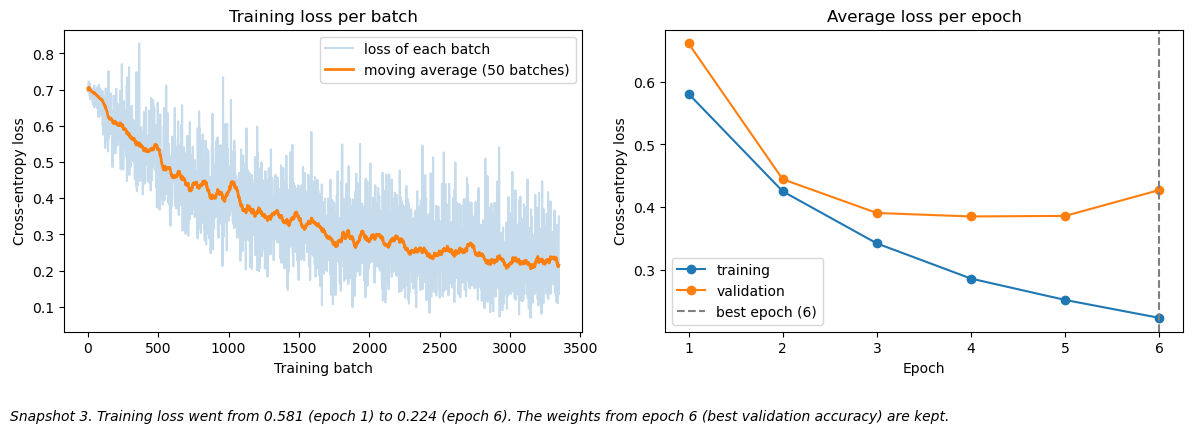

In [11]:
# Cell 12: Plot the training loss, Snapshot 3
fig, axes = plt.subplots(1, 2, figsize=(12, 4.3))
window = 50
axes[0].plot(batch_losses, alpha=0.25, label="loss of each batch")
axes[0].plot(pd.Series(batch_losses).rolling(window, min_periods=1).mean(),
             linewidth=2, label=f"moving average ({window} batches)")
axes[0].set(title="Training loss per batch", xlabel="Training batch", ylabel="Cross-entropy loss")
axes[0].legend()

epochs = range(1, EPOCHS + 1)
axes[1].plot(epochs, history["train_loss"], marker="o", label="training")
axes[1].plot(epochs, history["val_loss"], marker="o", label="validation")
axes[1].axvline(best_epoch, color="grey", linestyle="--", label=f"best epoch ({best_epoch})")
axes[1].set(title="Average loss per epoch", xlabel="Epoch", ylabel="Cross-entropy loss", xticks=list(epochs))
axes[1].legend()

caption_3 = (f"Snapshot 3. Training loss went from {history['train_loss'][0]:.3f} (epoch 1) to "
             f"{history['train_loss'][-1]:.3f} (epoch {EPOCHS}). The weights from epoch {best_epoch} "
             "(best validation accuracy) are kept.")
fig.text(0.01, 0.01, caption_3, fontsize=10, style="italic", wrap=True)
fig.tight_layout(rect=[0, 0.08, 1, 1])
fig.savefig(SCREENSHOT_DIR / "03_training_loss.png", dpi=150, facecolor="white")
plt.show()

## Snapshot 4, final test

Test accuracy 87.08% on 9,917 unseen reviews vs baseline 50% and target 82%: it reaches the target.
               pred negative  pred positive
true negative           3932           1008
true positive            273           4704


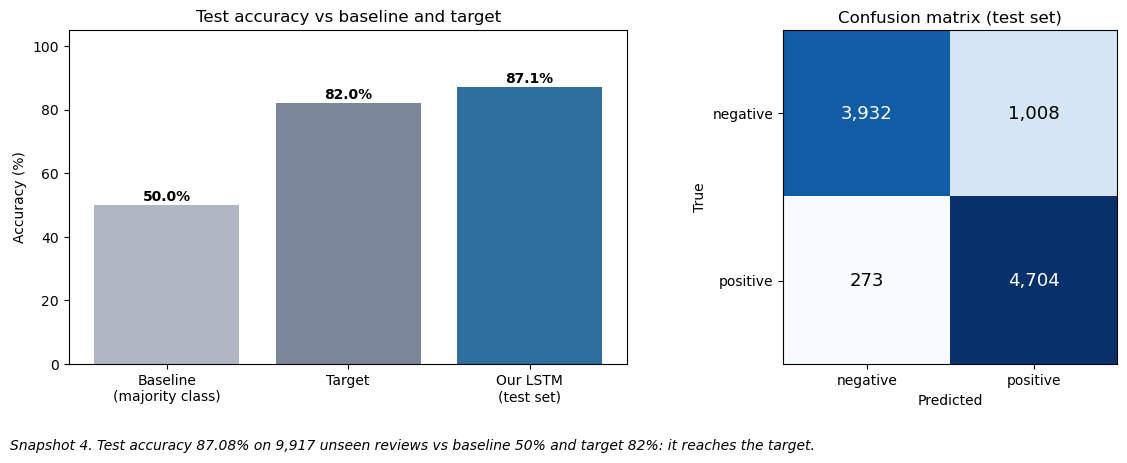

In [12]:
# Cell 13: Final test accuracy (the only use of the test set), Snapshot 4
model.load_state_dict(best_state)
model.eval()
predictions, true_labels = [], []
with torch.no_grad():
    for xb, lb, yb in test_loader:
        predictions.append(model(xb.to(DEVICE), lb).argmax(dim=1).cpu())
        true_labels.append(yb)

y_pred = torch.cat(predictions).numpy()
y_true = torch.cat(true_labels).numpy()
test_acc = (y_pred == y_true).mean()
cm = confusion_matrix(y_true, y_pred)

if test_acc >= TARGET_ACC:
    verdict = "reaches the target"
elif test_acc > BASELINE_ACC:
    verdict = "beats the baseline but is below the target"
else:
    verdict = "is not above the baseline, so the model did not learn"
result_line = (f"Test accuracy {test_acc:.2%} on {len(y_true):,} unseen reviews vs baseline "
               f"{BASELINE_ACC:.0%} and target {TARGET_ACC:.0%}: it {verdict}.")
print(result_line)
print(pd.DataFrame(cm, index=["true negative", "true positive"],
                   columns=["pred negative", "pred positive"]).to_string())

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.6), gridspec_kw={"width_ratios": [1.2, 1]})
names = ["Baseline\n(majority class)", "Target", "Our LSTM\n(test set)"]
values = [BASELINE_ACC * 100, TARGET_ACC * 100, test_acc * 100]
bars = ax1.bar(names, values, color=["#b0b7c3", "#7a8699", "#2f6f9f"])
for bar, value in zip(bars, values):
    ax1.text(bar.get_x() + bar.get_width() / 2, value + 1.5, f"{value:.1f}%", ha="center", fontweight="bold")
ax1.set(ylim=(0, 105), ylabel="Accuracy (%)", title="Test accuracy vs baseline and target")

ax2.imshow(cm, cmap="Blues")
for i in range(2):
    for j in range(2):
        ax2.text(j, i, f"{cm[i, j]:,}", ha="center", va="center", fontsize=13,
                 color="white" if cm[i, j] > cm.max() / 2 else "black")
ax2.set(xticks=[0, 1], yticks=[0, 1], xticklabels=["negative", "positive"],
        yticklabels=["negative", "positive"], xlabel="Predicted", ylabel="True",
        title="Confusion matrix (test set)")
fig.text(0.01, 0.01, "Snapshot 4. " + result_line, fontsize=10, style="italic", wrap=True)
fig.tight_layout(rect=[0, 0.07, 1, 1])
fig.savefig(SCREENSHOT_DIR / "04_test_accuracy.png", dpi=150, facecolor="white")
plt.show()

In [13]:
def predict_sentiment(text):
    ids, length, _ = encode(text)
    with torch.no_grad():
        logits = model(torch.tensor([ids]).to(DEVICE), torch.tensor([length]))
    p = torch.softmax(logits, dim=1)[0, 1].item()
    return ("positive" if p >= 0.5 else "negative"), p

for review in ["An absolute masterpiece. I loved every minute of it.",
               "Boring, predictable and far too long.",
               "I expected to hate it, but it was surprisingly good.",
               "Great cast, but the story was not good at all."]:
    label, p = predict_sentiment(review)
    print(f"{label:<9} P(positive) = {p:.2f}   {review}")

positive  P(positive) = 0.97   An absolute masterpiece. I loved every minute of it.
negative  P(positive) = 0.01   Boring, predictable and far too long.
positive  P(positive) = 0.91   I expected to hate it, but it was surprisingly good.
positive  P(positive) = 0.52   Great cast, but the story was not good at all.
